<a href="https://colab.research.google.com/github/1900690/pear_ripeness_analysis/blob/main/%E6%9E%9C%E5%AE%9F%E9%A0%82%E7%82%B9%E4%BB%98%E8%BF%91%E3%81%A7%E3%81%AE%E4%BA%8C%E5%80%A4%E5%8C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
WORK_DIR = '/content/drive/MyDrive/玉水写真'

import os
os.chdir(WORK_DIR)
os.getcwd()

'/content/drive/MyDrive/玉水写真'

In [ ]:
os.listdir()

['果実1.jpg',
 '果実2.jpg',
 '適熟E.jpg',
 '果実B.jpg',
 '果実C.jpg',
 '果実A.jpg',
 '果点拡大版A.jpg',
 '未熟D.jpg',
 '果実B拡大版.jpg',
 '果実C拡大版.jpg',
 '未熟D拡大版.jpg',
 '適熟E拡大版.jpg',
 '果実1拡大.jpg',
 '果実2拡大.jpg']

In [ ]:
import cv2

# 画像を読み込む（'適熟E.jpg' が現在のディレクトリにあると仮定）
image_path = '適熟E.jpg'
image = cv2.imread(image_path)

# 画像が正常に読み込まれたか確認する
if image is None:
    print(f"エラー: {image_path} から画像を読み込めませんでした")
else:
    # 画像をLab色空間に変換する
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Lab画像のサイズを出力する
    print(f"Lab画像の寸法: {lab_image.shape}")

Lab Image dimensions: (678, 687, 3)


In [ ]:
l_channel = lab_image[:, :, 0]

print(f"L-channel dimensions: {l_channel.shape}")

L-channel dimensions: (678, 687)


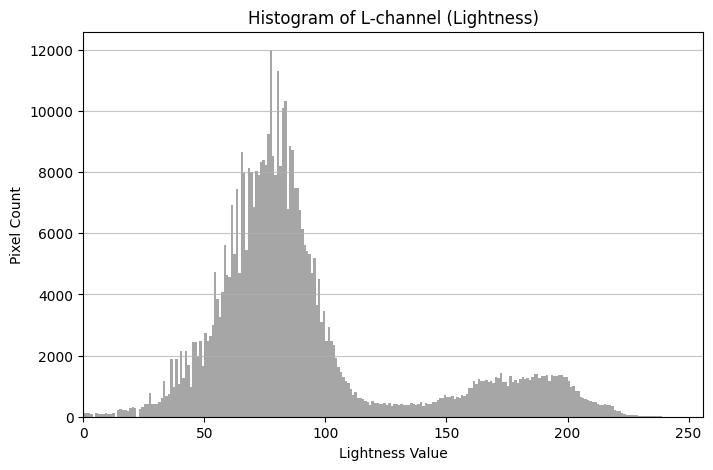

In [ ]:
import matplotlib.pyplot as plt

# Compute and plot the histogram of the L-channel
plt.figure(figsize=(8, 5))
plt.hist(l_channel.flatten(), bins=256, range=[0, 256], color='gray', alpha=0.7)
plt.title('Histogram of L-channel (Lightness)')
plt.xlabel('Lightness Value')
plt.ylabel('Pixel Count')
plt.xlim([0, 256])
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import cv2

# Apply Otsu's binarization to the L-channel
# The first return value is the optimal threshold, which we don't need to store here.
_, binary_l_channel = cv2.threshold(l_channel, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

print(f"Shape of binarized L-channel: {binary_l_channel.shape}")

Shape of binarized L-channel: (678, 687)


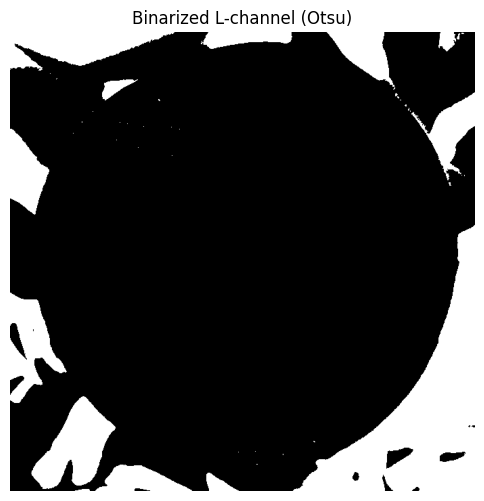

In [ ]:
import matplotlib.pyplot as plt

# Display the binarized L-channel image
plt.figure(figsize=(6, 6))
plt.imshow(binary_l_channel, cmap='gray')
plt.title('Binarized L-channel (Otsu)')
plt.axis('off')
plt.show()

In [ ]:
# Invert the binary_l_channel to make the black circles white and vice-versa
inverted_binary_l_channel = cv2.bitwise_not(binary_l_channel)

# Apply Otsu's binarization again to the inverted image
# This will find new thresholds within the previously dark regions
_, re_binarized_inverted_channel = cv2.threshold(inverted_binary_l_channel, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

print(f"Shape of re-binarized inverted L-channel: {re_binarized_inverted_channel.shape}")

Shape of re-binarized inverted L-channel: (678, 687)


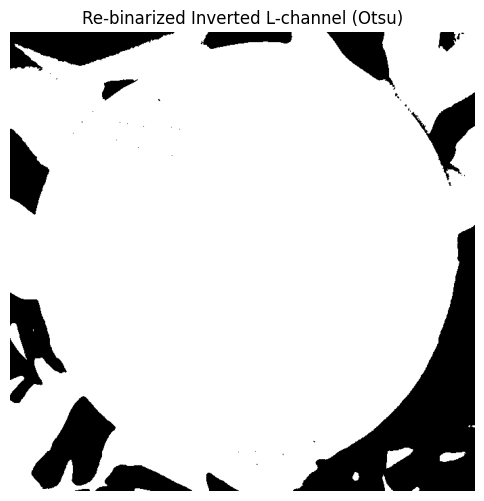

In [ ]:
# Display the re-binarized inverted L-channel image
plt.figure(figsize=(6, 6))
plt.imshow(re_binarized_inverted_channel, cmap='gray')
plt.title('Re-binarized Inverted L-channel (Otsu)')
plt.axis('off')
plt.show()

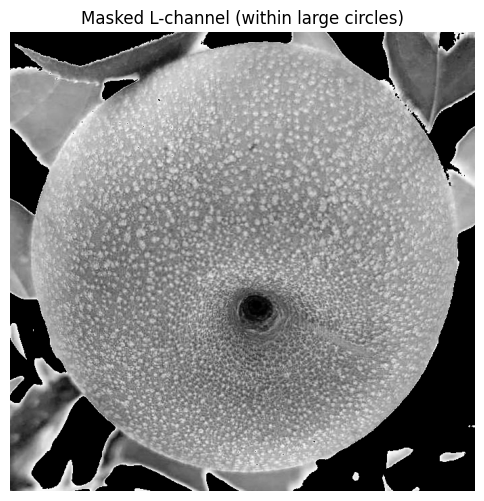

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Apply the mask to the original L-channel
# We multiply the l_channel by the mask (normalized to 0-1) to get L-channel values only within the mask
# First, convert re_binarized_inverted_channel to a floating point type and normalize it to 0-1
normalized_mask = re_binarized_inverted_channel.astype(float) / 255

# Apply the mask to the L-channel. Ensure both are of compatible type for multiplication.
# We'll convert l_channel to float for multiplication and then back to uint8.
masked_l_channel = (l_channel.astype(float) * normalized_mask).astype(np.uint8)

# Display the masked L-channel to verify
plt.figure(figsize=(6, 6))
plt.imshow(masked_l_channel, cmap='gray')
plt.title('Masked L-channel (within large circles)')
plt.axis('off')
plt.show()

Shape of binarized masked L-channel: (678, 687)


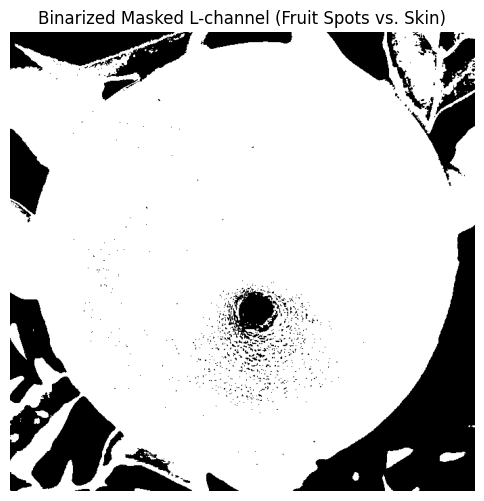

In [ ]:
# Apply Otsu's binarization to the masked L-channel
# To ensure Otsu's method works well, we might want to consider only the pixels within the mask for threshold calculation.
# However, cv2.threshold with THRESH_OTSU will find a global threshold. Let's try it directly first.
# We need to ensure that the background (0 values from the mask) doesn't skew the histogram too much for Otsu.
# A common approach is to only consider non-zero pixels for threshold calculation if the background is solid black.

# Let's create a temporary array with only the pixels we care about for Otsu's thresholding
pixels_for_otsu = masked_l_channel[masked_l_channel > 0] # Exclude the black background

if len(pixels_for_otsu) > 0: # Ensure there are pixels to binarize
    # If we want a threshold specific to the fruit, we can compute it on `pixels_for_otsu`.
    # However, cv2.threshold (with Otsu) expects the full image. Let's apply it directly.
    # If the background is 0, Otsu might produce a threshold that separates foreground from background.
    # We need to clarify if the user wants to separate fruit spots FROM fruit skin, or fruit from background.
    # Assuming separation of fruit spots from fruit skin *within* the fruit region.

    # A simple approach for separating within the fruit region is to apply Otsu on the masked image itself.
    # The threshold will be chosen to separate the main two modes in the masked_l_channel histogram.
    _, binarized_masked_l_channel = cv2.threshold(masked_l_channel, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    print(f"Shape of binarized masked L-channel: {binarized_masked_l_channel.shape}")

    # Display the binarized masked L-channel image
    plt.figure(figsize=(6, 6))
    plt.imshow(binarized_masked_l_channel, cmap='gray')
    plt.title('Binarized Masked L-channel (Fruit Spots vs. Skin)')
    plt.axis('off')
    plt.show()
else:
    print("No non-zero pixels found in the masked L-channel to perform binarization.")

Centroid of the selected central black region: (360, 414)
Radius of the white circle (large_circles_mask): 481.90 pixels
Calculated extraction radius (1/3 of white circle radius): 160 pixels


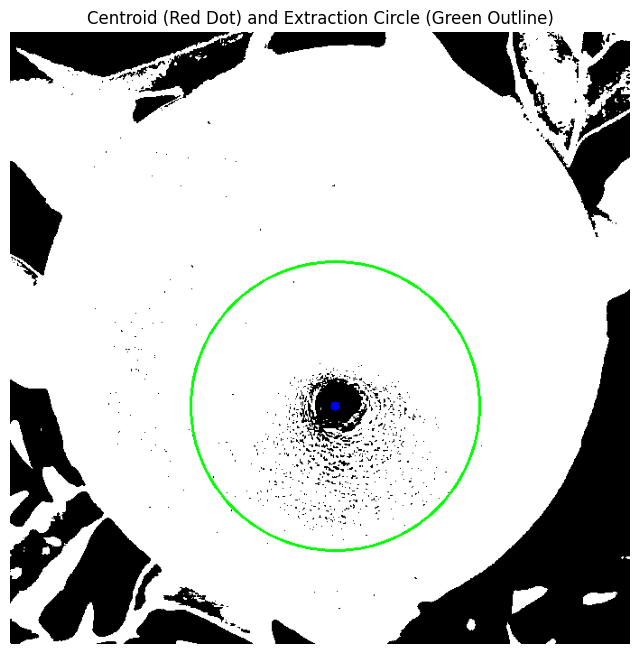

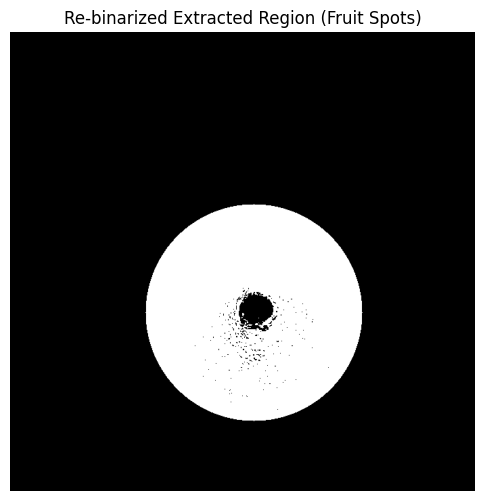

In [ ]:
import numpy as np

# Step 1: Identify the main 'black circle' and its centroid
# To find contours of black regions, we temporarily invert the image so that black regions become white.
# In binarized_masked_l_channel: 0 (black) = darker fruit skin/background, 255 (white) = bright fruit spots.
# So, to find contours of the *darker fruit skin/background* regions (the 'black circles' you refer to),
# we invert the image. Then, cv2.findContours will detect these now-white regions.
temp_inverted_for_black_contours = cv2.bitwise_not(binarized_masked_l_channel)

# Find contours in this temporarily inverted image. These contours now represent the *original black regions*.
black_regions_contours, _ = cv2.findContours(temp_inverted_for_black_contours.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter out very small contours that might be noise
min_black_contour_area = 50 # Adjust as needed based on the size of the black circles you expect
filtered_black_contours = [cnt for cnt in black_regions_contours if cv2.contourArea(cnt) > min_black_contour_area]

black_cx, black_cy = -1, -1 # Initialize with invalid coordinates

if filtered_black_contours:
    # User wants the black region in the 'middle of the image' that is 'surrounded by the white region'.
    # We'll interpret this as finding the black contour whose centroid is closest to the image center.
    image_center_x, image_center_y = binarized_masked_l_channel.shape[1] // 2, binarized_masked_l_channel.shape[0] // 2

    closest_contour = None
    min_distance = float('inf')

    for cnt in filtered_black_contours:
        M = cv2.moments(cnt)
        if M["m00"] != 0: # Avoid division by zero for contours with zero area
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])

            # Calculate distance from this centroid to the image center
            distance = np.sqrt((cx - image_center_x)**2 + (cy - image_center_y)**2)

            if distance < min_distance:
                min_distance = distance
                closest_contour = cnt
                black_cx, black_cy = cx, cy

    if closest_contour is None:
        print("Warning: No valid black contours found or unable to determine closest to center. Using image center.")
        black_cx, black_cy = image_center_x, image_center_y

else:
    print("Warning: No significant black contours found after filtering. Using image center.")
    black_cx, black_cy = masked_l_channel.shape[1] // 2, masked_l_channel.shape[0] // 2

print(f"Centroid of the selected central black region: ({black_cx}, {black_cy})")

# Step 2: Determine the effective radius of the 'white circle' (large_circles_mask)
# Find the largest contour in large_circles_mask to get its outline
contours_white, _ = cv2.findContours(re_binarized_inverted_channel.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

outer_radius = 0
if contours_white:
    largest_white_contour = max(contours_white, key=cv2.contourArea)
    # Find the minimum enclosing circle for this contour
    ((x_outer, y_outer), outer_radius) = cv2.minEnclosingCircle(largest_white_contour)
    print(f"Radius of the white circle (large_circles_mask): {outer_radius:.2f} pixels")
else:
    print("Warning: No contours found in large_circles_mask. Cannot determine white circle radius.")

# Step 3: Calculate the new extraction radius
if outer_radius > 0:
    extraction_radius = int(outer_radius / 3)
    print(f"Calculated extraction radius (1/3 of white circle radius): {extraction_radius} pixels")
else:
    extraction_radius = 50 # Default to a reasonable size if radius cannot be determined
    print(f"Using default extraction radius: {extraction_radius} pixels")

# --- Visualization for debugging ---
# Create a visualization image from the binarized_masked_l_channel
visualization_img = cv2.cvtColor(binarized_masked_l_channel, cv2.COLOR_GRAY2BGR)

# Draw the centroid of the selected black region (red dot)
cv2.circle(visualization_img, (black_cx, black_cy), 5, (0, 0, 255), -1)

# Draw the calculated extraction circle (green circle)
cv2.circle(visualization_img, (black_cx, black_cy), extraction_radius, (0, 255, 0), 2)

# Display the visualization
plt.figure(figsize=(8, 8))
plt.imshow(visualization_img)
plt.title('Centroid (Red Dot) and Extraction Circle (Green Outline)')
plt.axis('off')
plt.show()
# --- End Visualization ---

# Step 4: Create a new circular mask for extraction
extraction_mask = np.zeros_like(binarized_masked_l_channel)
cv2.circle(extraction_mask, (black_cx, black_cy), extraction_radius, 255, -1) # Draw filled circle

# Step 5: Apply the new mask to the original L-channel and then re-binarize
# Mask the original L-channel with the extraction_mask
l_channel_in_circular_roi = cv2.bitwise_and(l_channel, l_channel, mask=extraction_mask)

# Apply Otsu's binarization to this new masked L-channel
# Only consider non-zero pixels for Otsu's threshold if the background is solid black (0)
if np.max(l_channel_in_circular_roi) > 0: # Ensure there are non-zero pixels to binarize
    _, final_extracted_region = cv2.threshold(l_channel_in_circular_roi, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
else:
    final_extracted_region = np.zeros_like(l_channel_in_circular_roi) # If no pixels, result is all black

# Display the result
plt.figure(figsize=(6, 6))
plt.imshow(final_extracted_region, cmap='gray')
plt.title('Re-binarized Extracted Region (Fruit Spots)')
plt.axis('off')
plt.show()

検出された果点（白い領域）の数: 1


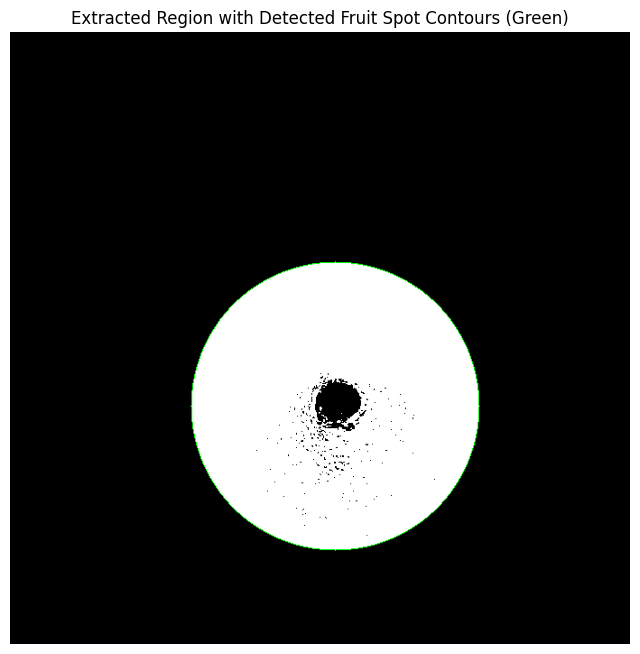

In [ ]:
# 検出された果点の輪郭を可視化して確認します。
# final_extracted_regionはすでに二値化されており、白い部分が果点です。

# 可視化用の画像を準備（元のLチャンネルのカラー版に輪郭を描画すると見やすい場合がある）
# または、final_extracted_region自体に輪郭を描画。
# ここではfinal_extracted_regionのBGR変換コピーに描画します。
visual_fruit_spots = cv2.cvtColor(final_extracted_region, cv2.COLOR_GRAY2BGR)

# final_extracted_regionから果点の輪郭を検出
# 白い領域の輪郭なので、そのままfindContoursを適用します。
fruit_spot_contours, _ = cv2.findContours(final_extracted_region.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 検出された輪郭を描画
# 緑色で輪郭を描画します
cv2.drawContours(visual_fruit_spots, fruit_spot_contours, -1, (0, 255, 0), 1) # (0,255,0)は緑色、1は線の太さ

print(f"検出された果点（白い領域）の数: {len(fruit_spot_contours)}")

# 結果を表示
plt.figure(figsize=(8, 8))
plt.imshow(visual_fruit_spots)
plt.title('Extracted Region with Detected Fruit Spot Contours (Green)')
plt.axis('off')
plt.show()

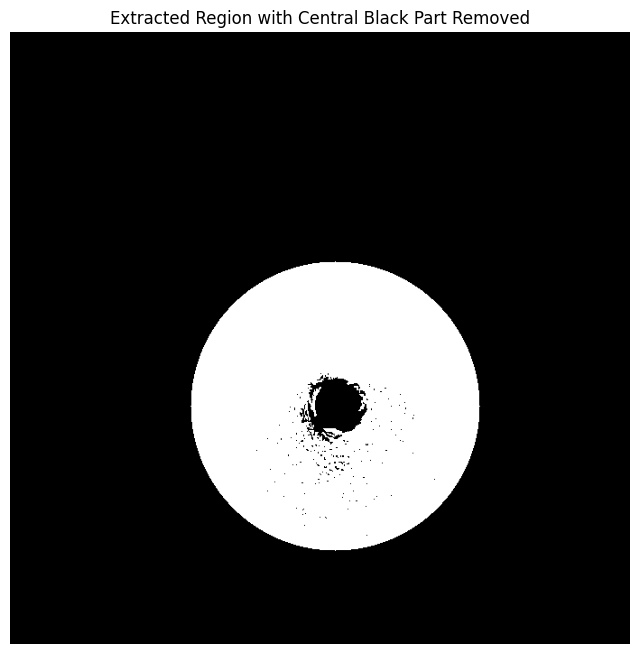

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a mask for the central black region (closest_contour)
# This mask will be 255 where the central black region is, and 0 elsewhere.
central_black_region_mask = np.zeros_like(final_extracted_region)
cv2.drawContours(central_black_region_mask, [closest_contour], -1, 255, cv2.FILLED)

# Invert this mask: the area *outside* central_black_region_mask becomes 255, and central_black_region_mask area becomes 0.
inverted_central_black_mask = cv2.bitwise_not(central_black_region_mask)

# Apply the inverted mask to final_extracted_region
# This will make the area corresponding to the original central black region (closest_contour) in
# final_extracted_region become 0, effectively 'cutting it out'.
image_without_central_black = cv2.bitwise_and(final_extracted_region, final_extracted_region, mask=inverted_central_black_mask)

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(image_without_central_black, cmap='gray')
plt.title('Extracted Region with Central Black Part Removed')
plt.axis('off')
plt.show()

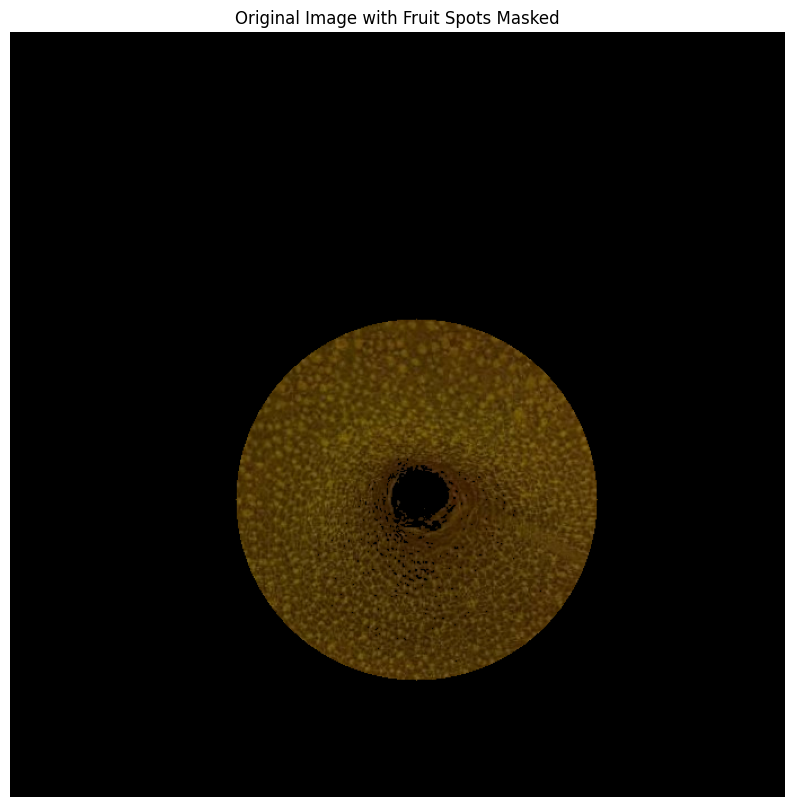

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ensure the original image is available (it was loaded as 'image')
# final_extracted_region is a single-channel (grayscale) image where fruit spots are 255 and background is 0.

# Create a 3-channel version of the final_extracted_region to use as a mask on the color image.
# This mask will be 255 (white) for fruit spots and 0 (black) elsewhere across all 3 channels.
binarized_fruit_spots_color_mask = cv2.cvtColor(final_extracted_region, cv2.COLOR_GRAY2BGR)

# Apply the mask to the original image.
# This operation will extract the fruit spot regions from the original color image.
# Pixels where the mask is 255 will keep their original color values, others will become black (0).
masked_original_image = cv2.bitwise_and(image, binarized_fruit_spots_color_mask)

# Display the result
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(masked_original_image, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib display
plt.title('Original Image with Fruit Spots Masked')
plt.axis('off')
plt.show()

Trimmed image saved to: /content/drive/MyDrive/玉水写真/適熟E果頂部付近.jpg


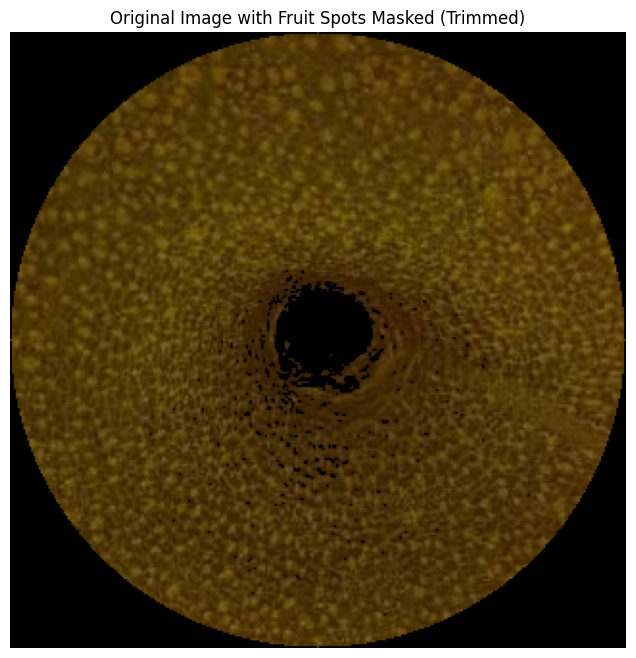

In [ ]:
import numpy as np

# Convert the masked_original_image to grayscale for easier bounding box detection
grayscale_masked_image = cv2.cvtColor(masked_original_image, cv2.COLOR_BGR2GRAY)

# Find the coordinates of all non-zero pixels
coords = cv2.findNonZero(grayscale_masked_image)

if coords is not None:
    # Get the bounding box from the non-zero coordinates
    x, y, w, h = cv2.boundingRect(coords)

    # Crop the original masked_original_image using the bounding box
    cropped_image = masked_original_image[y:y+h, x:x+w]

    # Define the output path for the trimmed image
    output_trimmed_image_path = os.path.join(WORK_DIR, '適熟E果頂部付近.jpg')

    # Save the trimmed image
    cv2.imwrite(output_trimmed_image_path, cropped_image)
    print(f"Trimmed image saved to: {output_trimmed_image_path}")

    # Display the trimmed image
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image with Fruit Spots Masked (Trimmed)')
    plt.axis('off')
    plt.show()
else:
    print("No non-black pixels found to trim the image.")

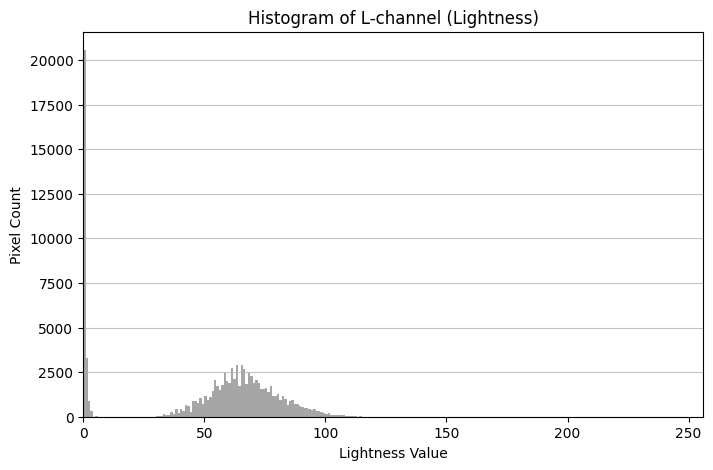

In [ ]:
import matplotlib.pyplot as plt

# Compute and plot the histogram of the L-channel
plt.figure(figsize=(8, 5))
plt.hist(l_channel.flatten(), bins=256, range=[0, 256], color='gray', alpha=0.7)
plt.title('Histogram of L-channel (Lightness)')
plt.xlabel('Lightness Value')
plt.ylabel('Pixel Count')
plt.xlim([0, 256])
plt.grid(axis='y', alpha=0.75)
plt.show()

Trimmed Lab Image dimensions: (321, 321, 3)
Trimmed L-channel dimensions: (321, 321)


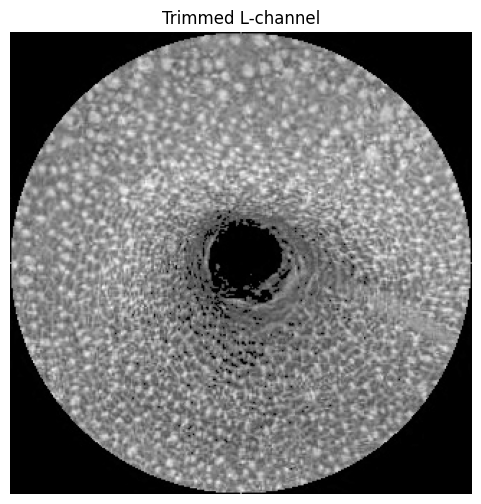

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the trimmed image
trimmed_image_path = os.path.join(WORK_DIR, '適熟E果頂部付近.jpg')
trimmed_image = cv2.imread(trimmed_image_path)

# Check if the image was loaded successfully
if trimmed_image is None:
    print(f"Error: Could not load trimmed image from {trimmed_image_path}")
else:
    # Convert the trimmed image to Lab color space
    trimmed_lab_image = cv2.cvtColor(trimmed_image, cv2.COLOR_BGR2LAB)

    # Extract the L-channel from the trimmed Lab image
    trimmed_l_channel = trimmed_lab_image[:, :, 0]

    print(f"Trimmed Lab Image dimensions: {trimmed_lab_image.shape}")
    print(f"Trimmed L-channel dimensions: {trimmed_l_channel.shape}")

    # Display the trimmed L-channel to verify
    plt.figure(figsize=(6, 6))
    plt.imshow(trimmed_l_channel, cmap='gray')
    plt.title('Trimmed L-channel')
    plt.axis('off')
    plt.show()

Shape of binarized trimmed L-channel: (321, 321)


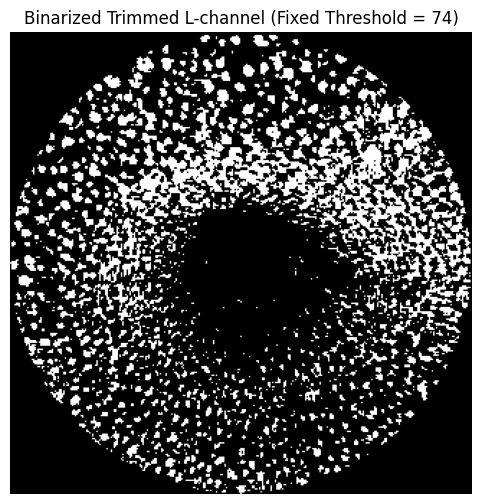

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Apply fixed threshold binarization to the trimmed L-channel
# Using a threshold of 74 as requested by the user
_, binarized_trimmed_l_channel = cv2.threshold(trimmed_l_channel, 74, 255, cv2.THRESH_BINARY)

print(f"Shape of binarized trimmed L-channel: {binarized_trimmed_l_channel.shape}")

# Display the binarized trimmed L-channel image
plt.figure(figsize=(6, 6))
plt.imshow(binarized_trimmed_l_channel, cmap='gray')
plt.title('Binarized Trimmed L-channel (Fixed Threshold = 74)')
plt.axis('off')
plt.show()

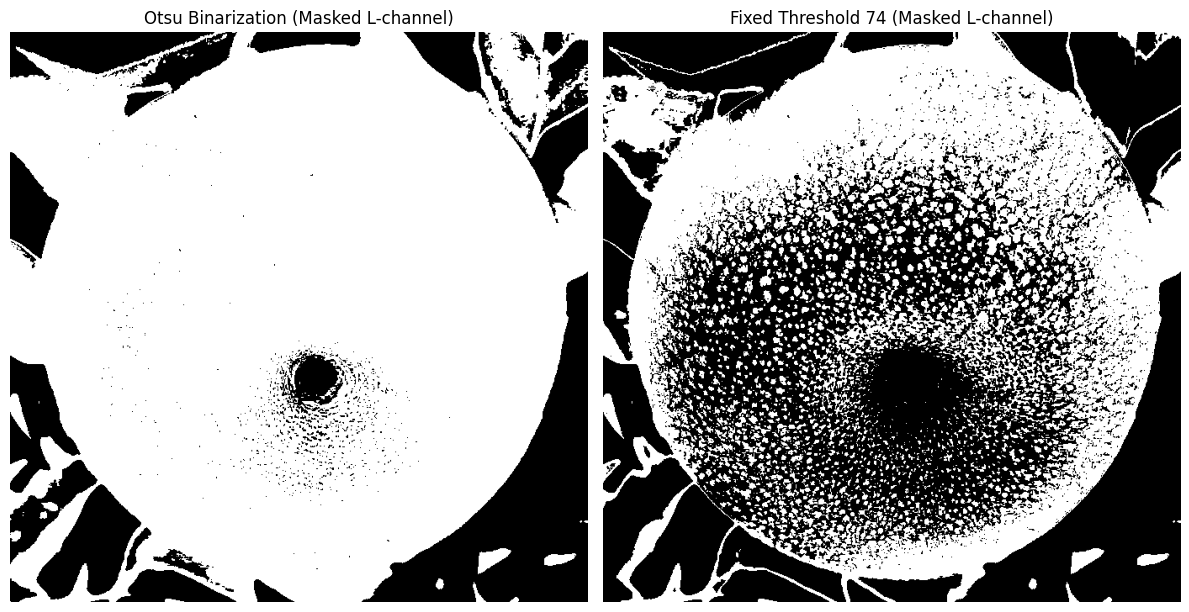

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Assuming `masked_l_channel` is available from previous steps
# and `binarized_masked_l_channel` (Otsu's result) is also available.

# 1. Apply fixed threshold of 74 to the masked L-channel
_, binarized_masked_l_channel_fixed_74 = cv2.threshold(masked_l_channel, 74, 255, cv2.THRESH_BINARY)

# 2. Display both images side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.imshow(binarized_masked_l_channel, cmap='gray')
plt.title('Otsu Binarization (Masked L-channel)')
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.imshow(binarized_masked_l_channel_fixed_74, cmap='gray')
plt.title('Fixed Threshold 74 (Masked L-channel)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Masking the L-channel with Fixed Threshold 74 Binarization and its Inverse

DEBUG: l_channel shape: (321, 321), dtype: uint8
DEBUG: binarized_masked_l_channel_fixed_74 shape: (678, 687), dtype: uint8
DEBUG: Resizing binarized_masked_l_channel_fixed_74 from (678, 687) to (321, 321)


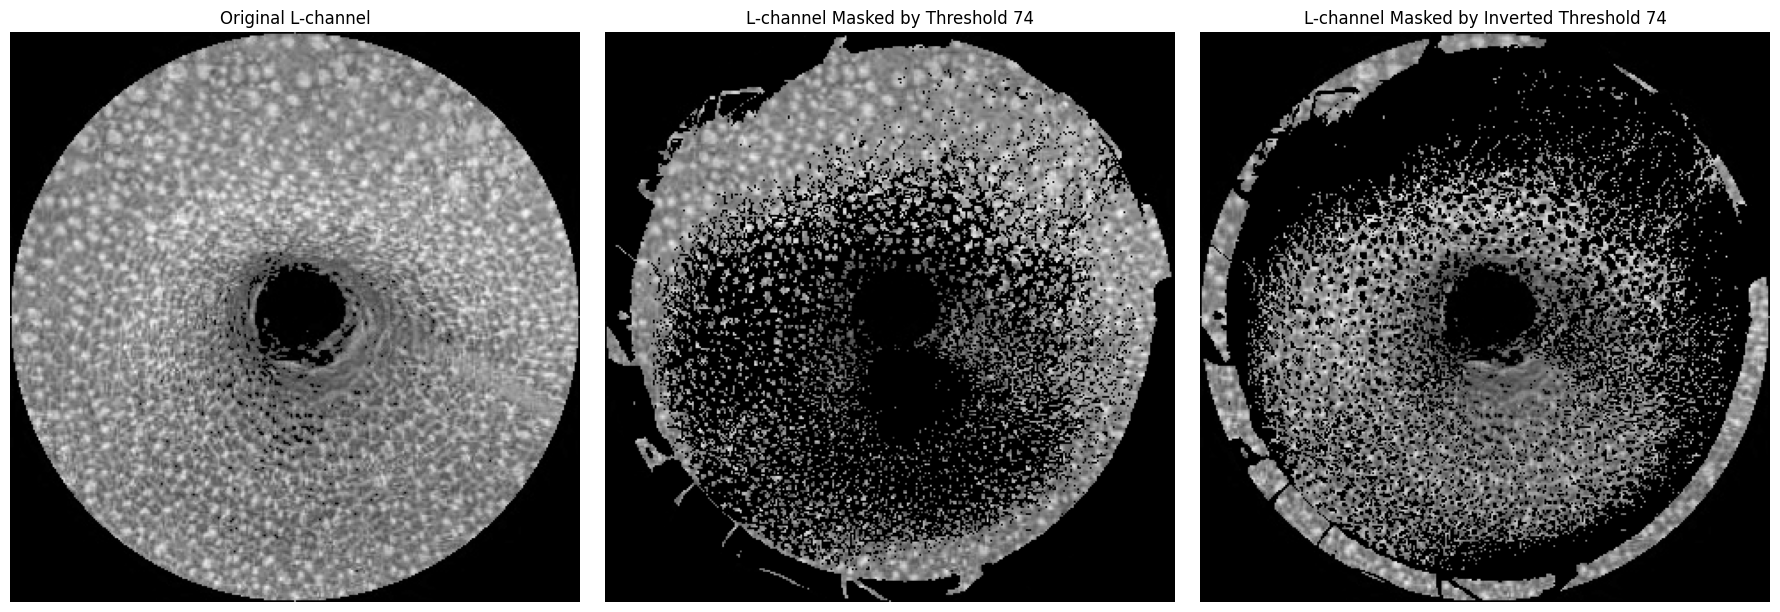

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Ensure l_channel and binarized_masked_l_channel_fixed_74 are available
# l_channel: Original L-channel from the Lab image
# binarized_masked_l_channel_fixed_74: Binarized image using fixed threshold 74 on masked L-channel

# Re-create binarized_masked_l_channel_fixed_74 for robustness,
# as there might have been a state issue. This assumes 'masked_l_channel' is available.
# If 'masked_l_channel' is not defined, this will raise a NameError, which would need prior resolution.
_, binarized_masked_l_channel_fixed_74 = cv2.threshold(masked_l_channel, 74, 255, cv2.THRESH_BINARY)

print(f"DEBUG: l_channel shape: {l_channel.shape}, dtype: {l_channel.dtype}")
print(f"DEBUG: binarized_masked_l_channel_fixed_74 shape: {binarized_masked_l_channel_fixed_74.shape}, dtype: {binarized_masked_l_channel_fixed_74.dtype}")

# Ensure the mask has the same dimensions as the L-channel and is 8-bit single channel
if binarized_masked_l_channel_fixed_74.shape != l_channel.shape:
    print(f"DEBUG: Resizing binarized_masked_l_channel_fixed_74 from {binarized_masked_l_channel_fixed_74.shape} to {l_channel.shape}")
    binarized_masked_l_channel_fixed_74 = cv2.resize(binarized_masked_l_channel_fixed_74, (l_channel.shape[1], l_channel.shape[0]), interpolation=cv2.INTER_NEAREST)

if binarized_masked_l_channel_fixed_74.dtype != np.uint8:
    print(f"DEBUG: Converting binarized_masked_l_channel_fixed_74 dtype from {binarized_masked_l_channel_fixed_74.dtype} to uint8")
    binarized_masked_l_channel_fixed_74 = binarized_masked_l_channel_fixed_74.astype(np.uint8)

# 1. Mask the original L-channel with the fixed threshold 74 binarization
masked_l_channel_with_74_threshold = cv2.bitwise_and(l_channel, l_channel, mask=binarized_masked_l_channel_fixed_74)

# 2. Create the inverted mask from binarized_masked_l_channel_fixed_74
inverted_binarized_masked_l_channel_fixed_74 = cv2.bitwise_not(binarized_masked_l_channel_fixed_74)

# 3. Mask the original L-channel with the inverted fixed threshold 74 binarization
masked_l_channel_with_inverted_74_threshold = cv2.bitwise_and(l_channel, l_channel, mask=inverted_binarized_masked_l_channel_fixed_74)

# 4. Display all three images side-by-side
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
plt.imshow(l_channel, cmap='gray')
plt.title('Original L-channel')
plt.axis('off')

plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
plt.imshow(masked_l_channel_with_74_threshold, cmap='gray')
plt.title('L-channel Masked by Threshold 74')
plt.axis('off')

plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
plt.imshow(masked_l_channel_with_inverted_74_threshold, cmap='gray')
plt.title('L-channel Masked by Inverted Threshold 74')
plt.axis('off')

plt.tight_layout()
plt.show()

Number of detected contours in trimmed image (fixed threshold): 1111


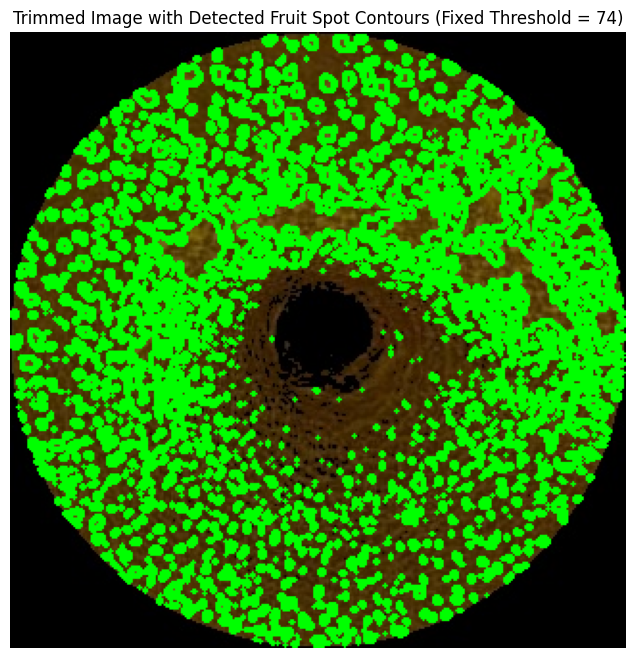

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Find contours in the binarized trimmed L-channel (using the fixed threshold result)
# Assuming white pixels (255) represent the regions of interest (fruit spots)
contours_trimmed_fixed_threshold, _ = cv2.findContours(binarized_trimmed_l_channel.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a copy of the original trimmed image to draw contours on
# Convert BGR to RGB for matplotlib display
trimmed_image_with_fixed_threshold_contours = cv2.cvtColor(trimmed_image.copy(), cv2.COLOR_BGR2RGB)

# Draw the detected contours in green
cv2.drawContours(trimmed_image_with_fixed_threshold_contours, contours_trimmed_fixed_threshold, -1, (0, 255, 0), 2) # Green color, thickness 2

print(f"Number of detected contours in trimmed image (fixed threshold): {len(contours_trimmed_fixed_threshold)}")

# Display the trimmed image with contours
plt.figure(figsize=(8, 8))
plt.imshow(trimmed_image_with_fixed_threshold_contours)
plt.title('Trimmed Image with Detected Fruit Spot Contours (Fixed Threshold = 74)')
plt.axis('off')
plt.show()

In [ ]:
抽出した領域で
果点面積：熟すと広がる
果点密度：果皮が広がることで一定面積当たりの密度は疎くなる
今回中心点から1/3の距離としたが……

#課題点と解決策の提案
Q.背景を消去してナシの果点のみを抽出するのが難しい

A.撮影条件を一定に合わせる。紙で筒を作ってその中を通して撮影することで、一定の距離かつ背景を排除することができる。



Q.背景を消去してナシの果点のみを抽出するのが難しい

A.撮影条件を一定に合わせる。紙で筒を作ってその中を通して撮影することで、一定の距離かつ背景を排除することができる。
